# The workbench

The live devising path, one call at a time, with everything it sends and everything it gets back on the page. Nothing here is a copy: the prompts are read out of `agents/` and `shared/`, and the calls are the ones `panel/devising.py` and `panel/continuing.py` make.

Where the product loops on its own — a repair, a check, the gate — there is a cell, so what it does silently in a container is visible here in order.

One afternoon is n=1. What to try is decided here; whether it worked is answered by `python -m research.run`.

In [1]:
import os
import secrets
import sys
import time
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import research.bench as bench  # noqa: E402
from agents.experience_deviser import ExperienceDeviser, experience_in, the_prompt  # noqa: E402
from orchestrator.router import FoundryConfig, FoundryRouter  # noqa: E402
from orchestrator.safety import (  # noqa: E402
    AzureContentSafetyGate,
    ContentSafetyConfig,
    screen_experience,
)
from shared.agents import AgentContext  # noqa: E402
from shared.ids import LearnerId  # noqa: E402
from shared.seal import Sealer, SealPurpose  # noqa: E402

bench.environment()

# Built exactly as `panel/devising.py` builds it, so the gate and the router here are the
# ones production uses. The safety key is per-process: the seal this gate mints travels
# nowhere, on this path or on that one.
ENVIRONMENT = dict(os.environ)
KEY = ENVIRONMENT.get("LANTERNINA_SAFETY_KEY", "").encode() or secrets.token_bytes(32)
GATE = AzureContentSafetyGate(
    ContentSafetyConfig.from_env(ENVIRONMENT),
    Sealer(SealPurpose.CONTENT_SAFETY, KEY, "orchestrator.safety"),
)
ROUTER = FoundryRouter(FoundryConfig.from_env(ENVIRONMENT), gate=GATE)
CTX = AgentContext(router=ROUTER, learner_id=LearnerId(""), learner_hints={}, now=time.time())
DEVISER = ExperienceDeviser()

print("prompt fingerprint:", bench.reload_prompts())

prompt fingerprint: bdbfb5b564f4


## The calls, in order

Five, and every one of them is the call the container makes. `panel/devising.py` runs 1 to 4 inside one request and returns; `panel/continuing.py` runs 6 when a page comes back off the glass.

```mermaid
sequenceDiagram
  autonumber
  participant P as panel/devising
  participant M as gpt-5.6
  participant S as Content Safety
  P->>M: which method — 60 names out of methods/
  M-->>P: a form and a move
  P->>M: the afternoon — about 34 000 characters
  M-->>P: one JSON document
  opt the format will not read it
    P->>M: repair_unreadable — the refusal and the answer
    M-->>P: the answer again
  end
  opt a check refuses it, once and no more
    P->>M: repair — the complaints and the document
    M-->>P: the document again
  end
  P->>S: the document's own words
  S-->>P: through, or SafetyBlocked
```

| # | call | what it is sent | what comes back | measured |
| --- | --- | --- | --- | --- |
| 1 | which method | `choosing`, and a sample of 60 method names | two ids and a reason | a few seconds |
| 2 | the afternoon | the whole standing instruction plus the household's material, about 34 000 characters | one JSON document: title, overview, themes, script, minutes, drawn, moments | 76–184 s, median about 140 |
| 3 | a repair | `repair`, what was refused, and the document as it was | the same JSON again | once, and only if something refused |
| 4 | the gate | the document's own words | a pass, or `SafetyBlocked` | seconds |
| 5 | the page | `page_maker.*`, built from the page's own words | one PNG | 25–35 s a page |
| 6 | the continuation | `experience_continuer.*`, the afternoon so far and what came back on the sheet | the rest of the moments | 15–25 s |

The stand-in is the one call in this notebook the house never makes: it is `research/calls.adolescent.md`, and it exists so an afternoon can be walked with nobody in the room.

Credentials are not in `env.ps1`: the router builds a `DefaultAzureCredential`, which finds the `az` session in the `AZURE_CONFIG_DIR` named there. If a call fails on authentication, run `az account get-access-token` in a terminal with that variable set — `az account show` reads the cache and succeeds even on an expired token.

**Four things this notebook does differently, and none of them changes what is sent.** A failed choosing call raises here and is drawn around in the container. A document the checks still refuse after its one repair raises `RefusedByTheChecks` in the container and is only printed here. The gate is not closed at the end. And the walk — the stand-in, and stepping through the moments — is `research/`, not the product: in a house a person does that.

## 1. The prompts, as they are

Every block, with the format's own numbers filled in. The placeholders left as `$name` are the ones that carry a household's material, and the cell after next is where they are filled.

In [2]:
P = bench.everything()

for key, text in P.items():
    print(f"{key:26} {len(text):6}")
print(f"{'':26} {sum(len(one) for one in P.values()):6}  in all")

task                         2077
format                       4935
shape-of-a-moment            2765
acts                         1099
marks-on-a-page              3466
ten-dimensions               1135
rules-head                     88
limits                        482
rules-tail                    713
asking                        376
manner-head                   391
how-the-text-reads            860
what-to-refuse                421
only-what-you-can-answer     1399
worth-doing                  5117
manner-tail                   114
method                        810
household                    1391
pitch                         516
stand-in                     1535
                            29690  in all


In [3]:
print(P["task"])

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely not known, and

## 2. The household

Everything that decides one afternoon, as one dictionary. `research/run.py` sends the same one to `devise_experience`.

In [4]:
from research.households import Household, Memory, arguments

HOUSE = Household(
    name="bench",
    interests=("i treni", "le mappe vecchie"),
    avoid=("i ragni",),
    load="middle",
    ink="middle",
    span="middle",
    sheets=2,
    note="",
)
MEMORY = Memory()  # no history: the first afternoon of this house
ARGS = arguments(HOUSE, MEMORY)

for name, value in ARGS.items():
    shown = value if isinstance(value, str) else repr(value)
    print(f"{name:12} {shown[:110] or '—'}")

capabilities frozenset({<HouseCapability.PRINT_A4: 'print_a4'>, <HouseCapability.SCAN_A4: 'scan_a4'>, <HouseCapability.SHOW
language     Italian
interests    ('i treni', 'le mappe vecchie')
avoid        ('i ragni',)
pitch        two things that have to be put side by side before either makes sense, and one turn where what looked true sto
sheets       2
note         —
already      ()
recent       ()
happened     —
counts       {"afternoonsRun": 0, "ranToTheEnd": 0, "endedEarly": 0, "stopped": 0, "sheetsWrittenOn": 0, "sheetsBlank": 0}
direction    Ask for about what the last ones asked for. Nothing here says to move either way.
ground       —


## 3. Call one: which method

A cheap call before the expensive one. It carries a sample of sixty names out of `methods/` and no records, so the corpus stays outside the prompt. The sample is there because the whole catalogue made the model pick the same pair twice out of twice: the same judgement on the same list gives the same answer, which was worse than drawing.

In [5]:
from shared.methods import CATALOGUE, by_id, draw, index, load, runnable

RUNNABLE = runnable(load(), capabilities=ARGS["capabilities"])
CATALOGUE_SENT = index(RUNNABLE, sample=CATALOGUE)
print(f"{len(RUNNABLE)} methods this house can run · {len(CATALOGUE_SENT)} characters of names\n")
print(CATALOGUE_SENT[:1200])

145 methods this house can run · 5174 characters of names

label-every-line-you-draw: join things with lines and label every line
depth-at-every-crossing: decide which line passes in front at each crossing
one-fact-that-changes-what-was-already-read: add one fact and make the same page mean something else (a move)
plan-of-a-place-you-know: draw a plan of a place you already know
both-ends-of-the-scale-before-the-middle: write both ends of the scale before you start
a-budget-and-what-each-unit-earned: spend a fixed budget, then write what each unit earned
the-ending-is-how-many-times-you-chose: let the ending be how many times you chose one way
an-exact-total-instead-of-a-clock: make them stop at an exact total, not at a time (a move)
the-seventh-word-down-a-printed-list: replace every noun with the seventh word further down
magic-square-part-filled: complete a square of numbers that adds up
a-module-from-an-office-that-does-not-exist: a form from an office that does not exist
a-comma-i

In [6]:
began = time.time()
WANTS_FORM, WANTS_MOVE, WHY = await DEVISER.choose(
    CTX,
    catalogue=CATALOGUE_SENT,
    interests=ARGS["interests"],
    avoid=ARGS["avoid"],
    already=ARGS["already"],
    pitch=ARGS["pitch"],
)
ASKED_FOR = by_id(RUNNABLE, [WANTS_FORM, WANTS_MOVE])
FORM = next((one for one in ASKED_FOR if not one.is_a_move), None)
MOVE = next((one for one in ASKED_FOR if one.is_a_move), None)
if FORM is None or MOVE is None:
    # What `panel/devising.py` does: a step that exists to improve an afternoon may never
    # be the step that costs one.
    FORM, MOVE = draw(RUNNABLE)
    print("the choice did not resolve; drew instead")
print(f"{time.time() - began:.1f} s · {FORM.method_id} + {MOVE.method_id}\n{WHY}")

11.7 s · what-changed-between-two-pictures + one-fact-that-changes-what-was-already-read
Two old railway maps must be compared side by side before one new fact overturns what their differences seemed to mean.


## 4. The whole prompt, before paying for it

In [7]:
PROMPT = the_prompt(**ARGS, form=FORM, move=MOVE)
print(f"{len(PROMPT)} characters\n")
print(PROMPT)

34016 characters

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuin

## 5. Call two: the afternoon

One answer, whole. Measured at 76–184 s, median about 140.

In [8]:
began = time.time()
ANSWER = await DEVISER.ask(CTX, **ARGS, form=FORM, move=MOVE)
print(f"{time.time() - began:.1f} s · {len(ANSWER)} characters back")
print(ROUTER.last_usage)

136.8 s · 12028 characters back
ModelUsage(deployment='gpt-5.6-sol-2026-07-09', request_id='036a046d-caeb-469f-b4e7-ae69052e204b', input_tokens=7803, output_tokens=9566, cached_input_tokens=0, reasoning_tokens=6214, size='', quality='')


What came back, exactly as it came.

In [9]:
print(ANSWER)

{"title":"Le sette correzioni di Marta","overview":"Confronta due copie di una vecchia mappa ferroviaria, cerchia sette cambi, li classifica e rivede il motivo attribuito a Marta. Dalla stampante escono un dossier cartografico e un avviso d'archivio. Alla fine restano un avviso piegato e una frase propria sulla decisione di Marta. Non serve altro. Il confronto fitto di piccoli segni può stancare gli occhi.","themes":["mappe ferroviarie","copie d'archivio","decisioni","gallerie","cambiamenti"],"script":"THE WORLD\nValnera è una stazione sotto una luce color stagno. La sala delle mappe odora di polvere e ferro freddo. Nessuno nomina la galleria oltre il fiume, benché ogni copia della linea le lasci intorno troppo spazio.\n\nTHE WAY IN\nDal vassoio della stampante sporge oggi un dossier che non era sul tavolo. Contiene due copie della stessa linea, entrambe appartenute a Marta. Si prende il dossier e lo si posa accanto alla matita.\n\nTHE QUESTION\nPerché Marta fece la seconda copia della

## 6. The format reads it

In [10]:
from shared.experience import ExperienceError

REFUSAL = ""
try:
    EXPERIENCE = experience_in(ANSWER)
except ExperienceError as exc:
    EXPERIENCE, REFUSAL = None, str(exc)
    print("the format would not read it:", REFUSAL)
else:
    print(f"{EXPERIENCE.title} · {len(EXPERIENCE.moments)} moments · {EXPERIENCE.minutes} min")

Le sette correzioni di Marta · 5 moments · 84 min


If it would not read it at all, the answer goes back up with the refusal. `repair_unreadable`.

In [11]:
if REFUSAL:
    began = time.time()
    EXPERIENCE = await DEVISER.repair_unreadable(
        CTX, answer=ANSWER, refusal=REFUSAL, language=ARGS["language"]
    )
    print(f"{time.time() - began:.1f} s · {EXPERIENCE.title}")
else:
    print("the format read it; nothing to repair")

the format read it; nothing to repair


## 7. The seven checks

`shared/experience_checks.py`. They read the shape of the document and not its sense, and a complaint that comes back every afternoon names the rule in the prompt to work on.

In [12]:
from shared.experience_checks import check

COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
print("; ".join(map(str, COMPLAINTS)) or "no complaints")

no complaints


One repair and no more, which is what `panel/devising.py` allows.

In [13]:
if COMPLAINTS:
    began = time.time()
    EXPERIENCE = await DEVISER.repair(
        CTX, refused=EXPERIENCE, complaints=COMPLAINTS, language=ARGS["language"]
    )
    COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
    print(f"{time.time() - began:.1f} s · after the repair: ")
    print("; ".join(map(str, COMPLAINTS)) or "no complaints")
else:
    print("nothing to repair")

nothing to repair


## 8. The gate

The chokepoint. Nothing on this path returns past it: the parse and the checks can refuse, but only screening lets something through.

In [14]:
began = time.time()
await screen_experience(GATE, EXPERIENCE, context="devising an afternoon")
DOCUMENT = EXPERIENCE.to_dict()
print(f"{time.time() - began:.1f} s · the gate let it through")

1.4 s · the gate let it through


## 9. What came out

Only what would reach somebody in the room.

In [15]:
from tools.as_it_arrives import read

COUNTED = read(DOCUMENT)

──────────────────────────────────────────────────────────────────────────────
  Le sette correzioni di Marta
  Confronta due copie di una vecchia mappa ferroviaria, cerchia sette cambi, li classifica e rivede il motivo attribuito a Marta. Dalla stampante escono un dossier cartografico e un avviso d'archivio. Alla fine restano un avviso piegato e una frase propria sulla decisione di Marta. Non serve altro. Il confronto fitto di piccoli segni può stancare gli occhi.
  84 minuti
──────────────────────────────────────────────────────────────────────────────

1. [hand_over] Due copie nel vassoio
    Posa il dossier sul tavolo.
    Confronta una riga alla volta.
    Cerchia ogni cambio a matita.
    Accanto, segna A, P o S.

    ┌─ Le due copie di Valnera
    │  (disegno: Two side-by-side grids, each five rows by fourteen cells. The left grid repeats circle, triangle, vertical bar, diamond, empty cell, with each row shifted one place. The right grid is identical except: r1c5 becomes circle,

And the script, which is what the parent approves and what whoever runs the afternoon reads.

In [16]:
print(EXPERIENCE.script)

THE WORLD Valnera è una stazione sotto una luce color stagno. La sala delle mappe odora di polvere e ferro freddo. Nessuno nomina la galleria oltre il fiume, benché ogni copia della linea le lasci intorno troppo spazio. THE WAY IN Dal vassoio della stampante sporge oggi un dossier che non era sul tavolo. Contiene due copie della stessa linea, entrambe appartenute a Marta. Si prende il dossier e lo si posa accanto alla matita. THE QUESTION Perché Marta fece la seconda copia della linea di Valnera? La risposta: Marta fece la seconda copia per deviare il treno postale dalla galleria che temeva instabile. Cosa la stabilisce: i sette cambi visibili fra le copie; la loro divisione in tre apparizioni, due perdite e due scambi; l'avviso che lega 3A–2P–2S a una deviazione proposta quando Marta temeva una galleria. L'operazione: confronto, classificazione e accostamento. La falsa risposta: la seconda copia sembra un aggiornamento successivo ai lavori; crolla quando l'avviso definisce quella prec

## 10. The walk

Run the four cells below in order, then run them again, until it is over. Each pass is one moment.

⚠️ `gpt-image-2` has capacity 2 in this region: two page calls within about 30 s answer 429. A page is 25–35 s and a few cents.

```mermaid
sequenceDiagram
  autonumber
  participant H as the house
  participant G as gpt-image-2
  participant M as gpt-5.6
  loop one moment at a time
    opt the moment hands a page over
      H->>G: the page, from its own words
      G-->>H: a PNG, printed and left on the table
    end
    opt it collects one and the outcome says ask
      H->>M: the afternoon so far, and what came back on the sheet
      M-->>H: the rest of the moments
    end
  end
```

The stand-in is the one call here the house never makes: `research/calls.adolescent.md`, so an afternoon can be walked with nobody in the room.

In [17]:
from IPython.display import Image, display

from agents.page_maker import PageMaker
from shared.experience import ASK, Collect, HandOver, Say, Weight

WEIGHT = Weight.STANDARD
MOOD = "una giornata normale, c'è voglia di fare qualcosa"

BY_ID = {one.id: one for one in EXPERIENCE.moments}
ORDER = [one.id for one in EXPERIENCE.moments]
AT = ORDER[0]
MINUTES = 0
DISPLAYS: list[str] = []
SHEET = ""
CAME = None


def show(moment) -> None:
    """What this moment puts in the room, and the ladder somebody stuck would meet."""
    global MINUTES, SHEET
    weighing = moment.at(WEIGHT)
    MINUTES += weighing.minutes
    print(f"[{moment.act}] {moment.heading}   ({weighing.minutes} min, {MINUTES} in)")
    for line in weighing.lines:
        print(f"   display: {line}")
        DISPLAYS.append(line)
    for rung in moment.help:
        print(f"     after {rung.after_minutes} min: {' '.join(rung.lines)}")
    if isinstance(moment, HandOver):
        page = moment.page
        SHEET = "\n".join(
            [f"[{page.kind}] {page.title}", *page.note]
            + [f"- {one.label} ({one.room})" for one in page.spaces]
        )
        print(f"\n   page [{page.kind}] {page.title}")
        for line in page.note:
            print(f"     {line}")
        for space in page.spaces:
            print(f"     [ {space.label} — {space.room} ]")
        print(f"     drawing: {page.illustration}")
    if isinstance(moment, Collect):
        print(f"   way out: {moment.way_out.heading} ({moment.way_out.in_hand})")
        for one in moment.outcomes:
            print(f"   if {one.when} -> {one.then}")


def next_id(moment, came: str | None = None) -> str | None:
    """Where the afternoon goes after this. None is an ending, ASK is a continuation."""
    if isinstance(moment, (Say, HandOver)):
        i = ORDER.index(moment.id)
        return ORDER[i + 1] if i + 1 < len(ORDER) else None
    if isinstance(moment, Collect):
        return next((one.then for one in moment.outcomes if str(one.when) == came), ASK)
    return None

**a.** Where we are.

In [18]:
M = BY_ID[AT]
show(M)

[hand_over] Due copie nel vassoio   (18 min, 18 in)
   display: Posa il dossier sul tavolo.
   display: Confronta una riga alla volta.
   display: Cerchia ogni cambio a matita.
   display: Accanto, segna A, P o S.
     after 4 min: Il sette nel margine è un confine. Ogni cerchio chiude un confronto.
     after 9 min: Segui la stessa riga nelle copie. Un vuoto può essere un cambio.
     after 15 min: Cerca tre A, due P, due S. Scrivi le lettere accanto ai cerchi.
     after 24 min: A: r1c5, r2c4, r4c2. P: r2c7, r5c10. S: r3c4, r5c12. I sette cambi sono questi.

   page [dossier] Le due copie di Valnera
     Due copie della linea, conservate da Marta.
     Il margine dichiara che i cambi sono sette.
     Il dossier chiama A apparso, P perso, S scambiato.
     I sette vanno cerchiati; accanto resta A, P o S.
     [ Ordine trovato — a_line ]
     [ Motivo attribuito a Marta — some_lines ]
     drawing: Two side-by-side grids, each five rows by fourteen cells. The left grid repeats circle, 

**b.** The page, if this moment hands one over.

40.6 s · 103281 bytes


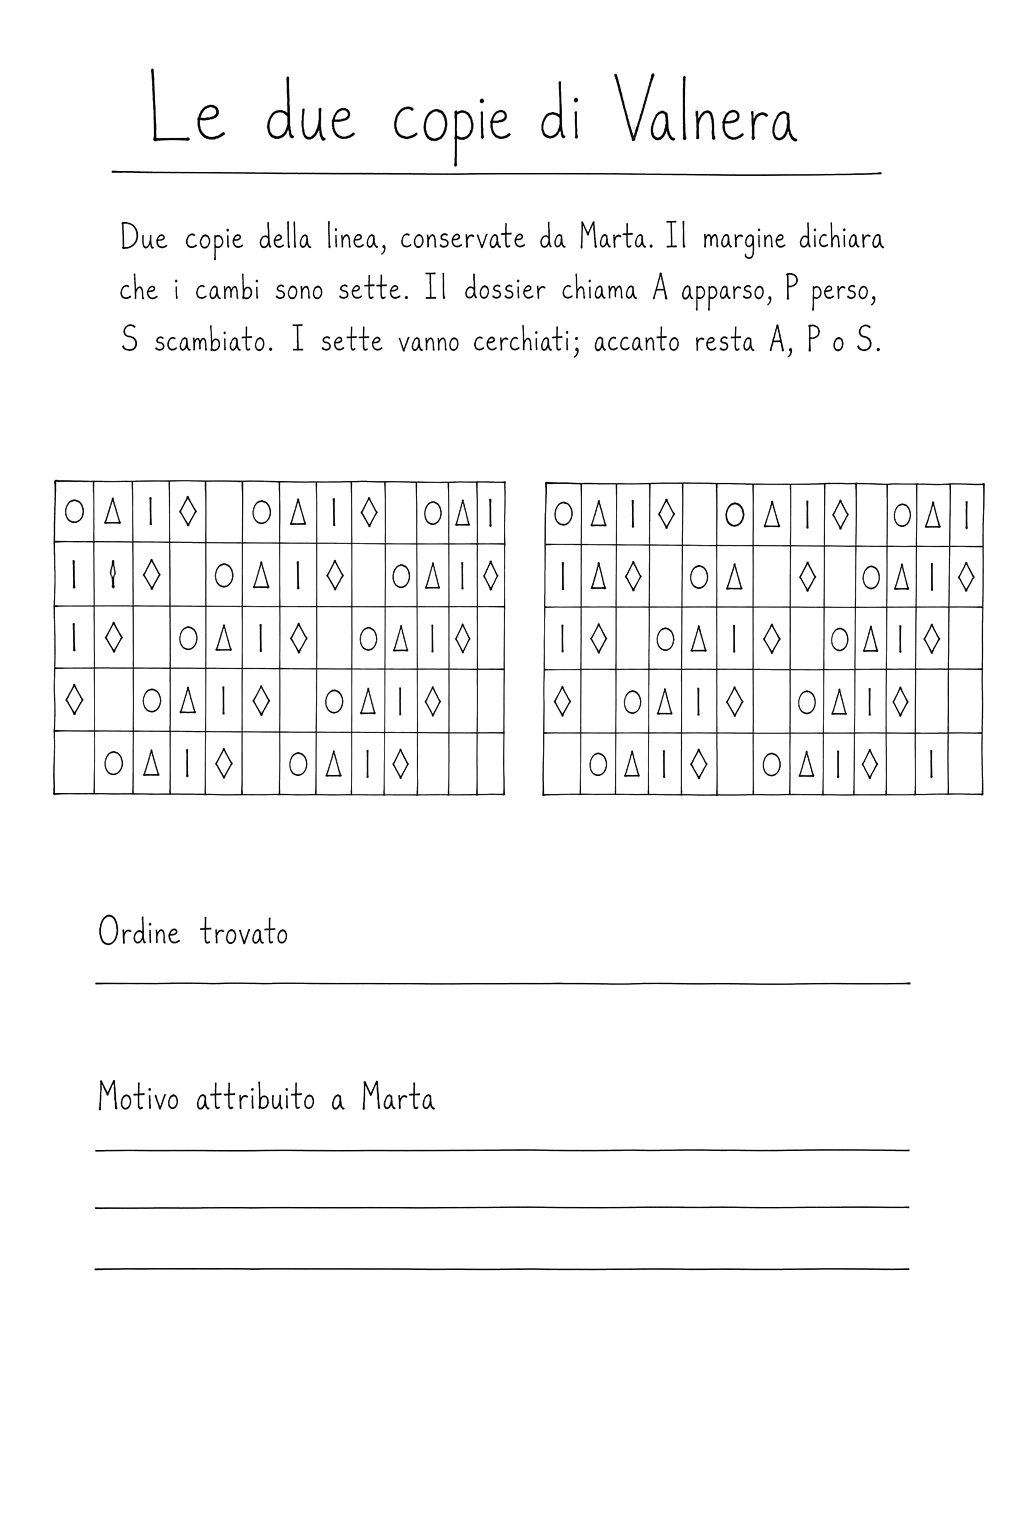

The page is a file card out of somebody's archive: a heading with a rule under it, a specimen drawn to one side, and a few ruled lines beside it. Never a grid, never a table, never a box for every answer.

Letter this large, as the title: "Le due copie di Valnera"
Letter this smaller, under the title: "Due copie della linea, conservate da Marta. Il margine dichiara che i cambi sono sette. Il dossier chiama A apparso, P perso, S scambiato. I sette vanno cerchiati; accanto resta A, P o S."
Leave one ruled line, long enough for a few words, with "Ordine trovato" lettered above it
Leave three ruled lines, with "Motivo attribuito a Marta" lettered above it

What the drawing on the page shows: Two side-by-side grids, each five rows by fourteen cells. The left grid repeats circle, triangle, vertical bar, diamond, empty cell, with each row shifted one place. The right grid is identical except: r1c5 becomes circle, r2c4 becomes triangle, r4c2 becomes diamond; r2c7 and r5c10 become empty; r3c4 c

In [19]:
if isinstance(M, HandOver):
    began = time.time()
    PNG, ASKED = await PageMaker().draw(CTX, M.page)
    (ROOT / "tmp").mkdir(exist_ok=True)
    (ROOT / "tmp" / f"{M.id}.png").write_bytes(PNG)
    print(f"{time.time() - began:.1f} s · {len(PNG)} bytes")
    display(Image(PNG, width=520))
    print(ASKED)
else:
    print(f"{M.act} — nothing to draw here")

**c.** What the person did with it, if this moment collects one.

In [20]:
from string import Template

from research.calls import what_they_did

if isinstance(M, Collect):
    print(Template(P["stand-in"]).substitute(
        displays="\n".join(DISPLAYS), sheet=SHEET, mood=MOOD, minutes=MINUTES
    ))
    DID = await what_they_did(
        CTX, displays=DISPLAYS, sheet=SHEET, mood=MOOD, minutes_in=MINUTES
    )
    CAME = "marks" if str(DID.get("came")) == "marks" else "blank"
    print(f"\n{CAME} · {DID.get('onIt')} · stop: {DID.get('stop')}\n{DID.get('why')}")
else:
    CAME = None
    print(f"{M.act} — nobody is being asked for anything here")

hand_over — nobody is being asked for anything here


**d.** Take the branch, and go back to **a**.

In [21]:
AT = next_id(M, CAME)
if AT is None:
    print("over")
elif AT == ASK:
    print("the outcome says ask: the rest is bought from the continuer, in the cell below")
else:
    print(f"next: {AT}  ({BY_ID[AT].act})")

next: first-reading  (say)


**e.** And if the branch said `ask`, buy the rest. This is `panel/continuing.py`, the second prompt, with its own gate and its own checks and no repair.

In [22]:
from panel.continuing import continue_experience

if AT == ASK:
    began = time.time()
    CARRYING_ON, SPENT = await continue_experience(
        experience=DOCUMENT,
        after=M.id,
        came=CAME,
        reading={"came": CAME, "reading": str(DID.get("onIt", ""))},
        now=time.time(),
        pitch=ARGS["pitch"],
    )
    print(f"{time.time() - began:.1f} s · {len(CARRYING_ON.moments)} more moments\n")
    for one in CARRYING_ON.moments:
        print(f"{one.id:26} {one.act:10} {one.heading}")
    # Carry on walking into what was just bought.
    BY_ID |= {one.id: one for one in CARRYING_ON.moments}
    ORDER += [one.id for one in CARRYING_ON.moments]
    AT = CARRYING_ON.moments[0].id
else:
    print("no continuation was asked for")

no continuation was asked for


## 11. Changing a block

The blocks are the files in `agents/` and `shared/`. Edit one in the editor, run `bench.reload_prompts()`, and go back to section 4: the fingerprint changes only when the text being sent changed.

When one is settled: `python -m tools.prompts --write`, then `python -m pytest -q`, then `python -m research.run --iterations 4 --seed 0 --label <name>` — six households, four iterations, about an hour, and the eight axes are the answer to whether it improved.

⚠️ Do not run `pytest` and a run at the same time: `tests/test_trail.py` fails with `Event loop is closed` on contention, and it looks like a real regression.

In [23]:
print("fingerprint:", bench.reload_prompts())

fingerprint: bdbfb5b564f4
